In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from tqdm.notebook import tqdm

In [54]:
import json
import os
from pathlib import Path
import re
from collections import Counter
import random
import math
import time

## Sample papers from Arxiv (metadata)

Download metadata from the [Kaggle page](https://www.kaggle.com/datasets/Cornell-University/arxiv)

In [4]:
json_path = Path("../data/arxiv-metadata-oai-snapshot.json")

In [5]:
with open(json_path, encoding='utf-8') as f:
    arxiv_meta_json_str = f.read()

In [6]:
arxiv_meta_json_str.count('\n')

2677526

In [29]:
arxiv_meta_json_lines = arxiv_meta_json_str.split('\n')

In [30]:
json.loads(arxiv_meta_json_lines[23])

{'id': '0704.0024',
 'submitter': 'Mikhail Kostylev',
 'authors': 'A.A. Serga, M. Kostylev, and B. Hillebrands',
 'title': 'Formation of quasi-solitons in transverse confined ferromagnetic film\n  media',
 'comments': "First appeared in Prof. B. Hillebrands' research group Annual Report\n  2005 (http://www.physik.uni-kl.de/w_hilleb/ann05.html); also presented at\n  Intermag'2006 Conference: M. Kostylev, A.A. Serga, and B. Hillebrands,\n  Digests of International Magnetic Conference, May 8-12, 2006, San Diego, USA,\n  FV03 (2006)",
 'journal-ref': None,
 'doi': None,
 'report-no': None,
 'categories': 'nlin.PS',
 'license': None,
 'abstract': '  The formation of quasi-2D spin-wave waveforms in longitudinally magnetized\nstripes of ferrimagnetic film was observed by using time- and space-resolved\nBrillouin light scattering technique. In the linear regime it was found that\nthe confinement decreases the amplitude of dynamic magnetization near the\nlateral stripe edges. Thus, the so-calle

In [11]:
arxiv_meta_dicts = []
print("Parsing each line into JSON")
for line in tqdm(arxiv_meta_json_lines):
    line = line.strip()
    if line:
        arxiv_meta_dicts.append(json.loads(line))

Parsing each line into JSON


  0%|          | 0/2677527 [00:00<?, ?it/s]

In [12]:
arxiv_meta_df = pd.DataFrame(arxiv_meta_dicts)

In [31]:
arxiv_meta_df.head()

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,None,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,None,math.CO,None,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
4,0704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,None,"Illinois J. Math. 52 (2008) no.2, 681-689",None,None,math.CA math.FA,None,In this paper we show how to compute the $\L...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]"


In [17]:
categories_all = []
for cates in arxiv_meta_df['categories']:
    categories_all.extend(re.split(r"\s+", cates))
unique_categories = set(categories_all)
print(f"# unique categories: {len(unique_categories)} (# total: {len(categories_all)})")

# unique categories: 176 (# total: 4589636)


Text(0.5, 1.0, 'Category Distribution')

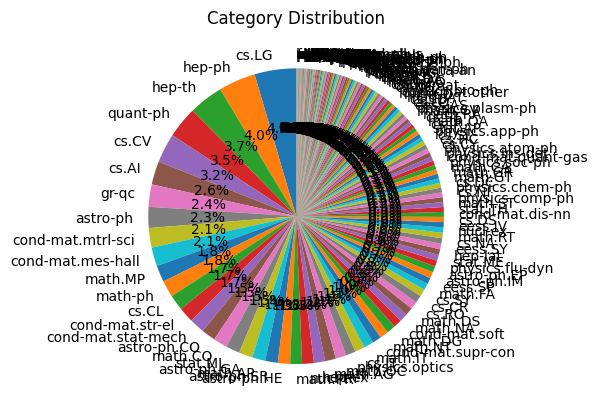

In [34]:
cates_counter = Counter(categories_all)
cates_counts_sorted_inds = np.argsort(cates_counts_unsorted)[::-1]
cates_counts_unsorted = np.array(list(cates_counter.values()))
cates_names_unsorted = np.array(list(cates_counter.keys()))
plt.pie(cates_counts_unsorted[cates_counts_sorted_inds],
        labels=cates_names_unsorted[cates_counts_sorted_inds], autopct='%1.1f%%', startangle=90)
plt.title('Category Distribution')
#plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.
#plt.show()

In [40]:
top_p = 0.9
top_p_count = round(top_p * len(categories_all))
count_cumsum = 0
top_p_categories = []
for idx in tqdm(cates_counts_sorted_inds):
    cnt = cates_counts_unsorted[idx]
    count_cumsum += cnt
    if count_cumsum <= top_p_count:
        top_p_categories.append([str(cates_names_unsorted[idx]), int(cnt)])
print("Top {:.0f}% categories (#={}): {}".format(100*top_p, len(top_p_categories), top_p_categories))

  0%|          | 0/176 [00:00<?, ?it/s]

Top 90% categories (#=85): [['cs.LG', 208116], ['hep-ph', 185725], ['hep-th', 171996], ['quant-ph', 158514], ['cs.CV', 147179], ['cs.AI', 117372], ['gr-qc', 112061], ['astro-ph', 105380], ['cond-mat.mtrl-sci', 97743], ['cond-mat.mes-hall', 94148], ['math.MP', 83009], ['math-ph', 83009], ['cs.CL', 79080], ['cond-mat.str-el', 76747], ['cond-mat.stat-mech', 76042], ['astro-ph.CO', 70491], ['math.CO', 70043], ['stat.ML', 69651], ['astro-ph.GA', 68471], ['math.AP', 66025], ['astro-ph.SR', 63218], ['astro-ph.HE', 61272], ['math.PR', 59291], ['nucl-th', 58950], ['hep-ex', 55850], ['math.AG', 54750], ['math.OC', 52710], ['physics.optics', 49599], ['cs.IT', 49336], ['math.IT', 49336], ['cond-mat.supr-con', 44530], ['math.NT', 44059], ['math.DG', 43914], ['cond-mat.soft', 41595], ['math.NA', 41253], ['math.DS', 38711], ['cs.RO', 38687], ['cs.CR', 37924], ['cs.SY', 36123], ['math.FA', 32645], ['eess.SP', 32068], ['astro-ph.IM', 31166], ['astro-ph.EP', 30948], ['physics.flu-dyn', 30060], ['stat.ME

In [46]:
n_samples = 5000
weights_sum = 0
for cate_name, cate_weight in top_p_categories:
    weights_sum += cate_weight

sampled_ids = set()
for cate_name, cate_weight in tqdm(top_p_categories, desc="Sampling"):
    cate_df_nodup = arxiv_meta_df[arxiv_meta_df['categories'].str.contains(cate_name) & (~arxiv_meta_df['id'].isin(sampled_ids))]
    n_samples_cate = round(n_samples * (cate_weight / weights_sum))
    sampled_row_indices = random.choices(range(len(cate_df_nodup)), k=n_samples_cate)
    n_sampled_ids_old = len(sampled_ids)
    for idx in sampled_row_indices:
        sampled_ids.add(cate_df_nodup.iloc[idx]['id'])
print("Sampled {} paper ids".format(len(sampled_ids)))

Sampling:   0%|          | 0/85 [00:00<?, ?it/s]

Sampled 5004 paper ids


In [47]:
arxiv_meta_df[arxiv_meta_df['id'].isin(sampled_ids)]

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
20,0704.0021,Yuichi Togashi,"Vanessa Casagrande, Yuichi Togashi, Alexander ...",Molecular Synchronization Waves in Arrays of A...,"5 pages, 4 figures","Phys. Rev. Lett. 99, 048301 (2007)",10.1103/PhysRevLett.99.048301,None,nlin.PS physics.chem-ph q-bio.MN,None,Spatiotemporal pattern formation in a produc...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-07-24,"[[Casagrande, Vanessa, ], [Togashi, Yuichi, ],..."
687,0704.0688,Lionel Levine,Lionel Levine and Yuval Peres,Strong Spherical Asymptotics for Rotor-Router ...,"[v3] Added Theorem 4.1, which generalizes Theo...","Potential Analysis 30, no. 1 (Jan. 2009), 1--2...",10.1007/s11118-008-9104-6,None,math.PR cond-mat.stat-mech math-ph math.CO mat...,http://arxiv.org/licenses/nonexclusive-distrib...,The rotor-router model is a deterministic an...,"[{'version': 'v1', 'created': 'Thu, 5 Apr 2007...",2009-12-05,"[[Levine, Lionel, ], [Peres, Yuval, ]]"
1261,0704.1262,Mahir S. Hussein,"J. X. Carvalho, M. S. Hussein, M. P. Pato and ...",Symmetry Breaking Study with Deformed Ensembles,"12 pages, 5 figures",None,None,None,physics.data-an cond-mat.other nlin.CD nucl-th,None,A random matrix model to describe the coupli...,"[{'version': 'v1', 'created': 'Tue, 10 Apr 200...",2007-11-18,"[[Carvalho, J. X., ], [Hussein, M. S., ], [Pat..."
1691,0704.1692,Lujun Fang,"Zhongzhi Zhang, Lujun Fang, Shuigeng Zhou, and...",Effects of accelerating growth on the evolutio...,Final version accepted for publication in Phys...,"Physica A, 2009, 388:225-232.",10.1016/j.physa.2008.10.008,None,physics.soc-ph,http://arxiv.org/licenses/nonexclusive-distrib...,Many real systems possess accelerating stati...,"[{'version': 'v1', 'created': 'Fri, 13 Apr 200...",2008-11-20,"[[Zhang, Zhongzhi, ], [Fang, Lujun, ], [Zhou, ..."
2075,0704.2076,Jiannis Pachos,Paolo Maraner and Jiannis K. Pachos,Universal Features of Dimensional Reduction Sc...,"16 pages, no figures, references added","AnnalsPhys.323:2044-2072,2008",10.1016/j.aop.2007.11.004,None,hep-th gr-qc math-ph math.DG math.MP quant-ph,None,Many features of dimensional reduction schem...,"[{'version': 'v1', 'created': 'Mon, 16 Apr 200...",2008-11-26,"[[Maraner, Paolo, ], [Pachos, Jiannis K., ]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2673787,quant-ph/9704005,None,"D. Han, Y. S. Kim, and Marilyn E. Noz","O(3,3)-like Symmetries of Coupled Harmonic Osc...","RevTeX, 24 pages, no figures, preliminary vers...",None,None,None,quant-ph hep-th,None,"In classical mechanics, the system of two co...","[{'version': 'v1', 'created': 'Thu, 3 Apr 1997...",2007-05-23,"[[Han, D., ], [Kim, Y. S., ], [Noz, Marilyn E...."
2674471,quant-ph/9803007,Chau Hoi Fung,"M. Ardehali, H. F. Chau and Hoi-Kwong Lo",Efficient Quantum Key Distribution,Minor revisions for clarification. One author ...,None,None,None,quant-ph,None,We devise a simple modification that essenti...,"[{'version': 'v1', 'created': 'Tue, 3 Mar 1998...",2007-05-23,"[[Ardehali, M., ], [Chau, H. F., ], [Lo, Hoi-K..."
2676034,quant-ph/9907087,Alexander S. Holevo,A. S. Holevo,Reliability function of general classical-quan...,"15 pages, partially reported at the Workshop o...",None,10.1109/18.868501,None,quant-ph,None,In information theory the reliability functi...,"[{'version': 'v1', 'created': 'Tue, 27 Jul 199...",2016-11-17,"[[Holevo, A. S., ]]"
2676056,quant-ph/9907110,Oliver Cohen,Oliver Cohen,Quantifying nonorthogonality,Accepted for publication in Phys. Rev. A,None,10.1103/PhysRevA.60.4349,None,quant-ph,None,An exploratory approach to the possibility o...,"[{'version': 'v1', 'created': 'Fri, 30 Jul 199...",2009-10-31,"[[Cohen, Oliver, ]]"


In [51]:
sample_ids_out_path = Path("out/sampled_ids.csv")
sample_ids_out_path.parent.mkdir(parents=True, exist_ok=True)
with open(sample_ids_out_path, 'w', encoding='utf-8') as f:
    arxiv_meta_df[arxiv_meta_df['id'].isin(sampled_ids)].to_csv(f, index=False)
print("Written {} sampled Arxiv paper csv to: {}".format(len(sampled_ids), sample_ids_out_path))

Written 5004 sampled Arxiv paper csv to: out/sampled_ids.csv


In [53]:
arxiv_meta_df[arxiv_meta_df['id'].str.contains(' ')]
# Since an id may contain slashes ('/') but no space, a slash will be replaced with a space for file names

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed


### Download samples

Even though according to the [Kaggle page](https://www.kaggle.com/datasets/Cornell-University/arxiv) files are downloadable from the GCS bucket it is not trivial to identify the address from the ids, so we will be downloading directly from the web instead.

In [ ]:
# Preferrably run following in a separate script 

# import requests
# import time
# from pathlib import Path
# import random

# import pandas as pd
# from tqdm import tqdm

# sample_ids_out_path = Path("out/sampled_ids.csv")

with open(sample_ids_out_path, encoding='utf-8') as f:
    sampled_df = pd.read_csv(f)
print("Found {} PDFs to download".format(len(sampled_df)))

pdfs_save_dirpath = Path("out/pdfs/sampled/")
pdfs_save_dirpath.mkdir(parents=True, exist_ok=True)
print("PDFs will be downloaded to: {}".format(pdfs_save_dirpath))

for i in (pbar := tqdm(range(len(sampled_df)))):
    row = sampled_df.iloc[i]
    web_url = "https://arxiv.org/pdf/{}".format(row['id'])
    resp = requests.get(web_url)
    out_path = pdfs_save_dirpath / (row['id'].replace('/', ' ') + ".pdf")
    if out_path.is_file():
        pbar.set_description("File exists; skipping")
    else:
        with open(out_path, 'wb') as f:
            f.write(resp.content)
        pbar.set_description("Downloading PDF (id: {}, title: {})".format(row['id'], row['title']))
        time.sleep(3 * random.random())